# GTO interface
We need to build an interface, because with the use of simply primitives, it is very cumbersome to work. Therefore, we are going to build an enhanced GTOClass, that handles with the angular momentum not efficienty, but less problematically. 

In [27]:
from py_mods.src.integrals.GTO import GTO, create_normalized_GTO, generate_angular_momentum_projections, S_3D, T_3D, V_3D, eri
from py_mods.src.SCF.plot_utilities import plot_map
from dataclasses import dataclass

We start defining the `GTOClass` with:  

In [28]:
from numpy.typing import NDArray
import numpy as np 

@dataclass
class CGTOClass:
    R: NDArray[np.float64] # position of the basis
    exps: NDArray[np.float64] # exponents
    N_a: float # normalization constant
    d_i: NDArray[np.float64] # contraction coefficients
    total_l: int
    l_dim: int # number of projections with this angular momentum
    l_projections: NDArray[np.int32] # all the projections for this angular momentum
    primitives: list[GTO] # we actually need these because of the normalization constants


We need to generate a factory method again:

In [29]:
def create_CGTOClass(
    R: NDArray[np.float64],
    exps: NDArray[np.float64],
    d_i: NDArray[np.float64],
    total_L: int,
) -> CGTOClass:
    """Factory function to create a GTOClass object with all its primitives and projections.

    Parameters
    ----------
    R : NDArray[np.float64]
        Center of the GTO.
    exps : NDArray[np.float64]
        Exponents of the primitives.
    d_i : NDArray[np.float64]
        Contraction coefficients of the primitives.
    total_L : int
        Total angular momentum of the GTO.

    Returns
    -------
    GTOClass
        The constructed GTOClass object.
    """
    l_projections = generate_angular_momentum_projections(total_L)
    l_dim = l_projections.shape[0]
    primitives = [create_normalized_GTO(R, exp, total_L) for exp in exps]
    

    unnormalized_cgto =  CGTOClass(
        R=R,
        exps=exps,
        d_i=d_i,
        N_a=1,
        total_l=total_L,
        l_dim=l_dim,
        l_projections=l_projections,
        primitives=primitives,
    )

    N_a = calculate_normalization_constant(unnormalized_cgto)

    unnormalized_cgto.N_a = N_a

    return unnormalized_cgto


def S_GTO_proj(cont_1: CGTOClass, proj_idx_1: int, cont_2: CGTOClass, proj_idx_2: int):
    """Overlap integral between two contracted GTOs with specific angular momentum projections.

    Parameters
    ----------
    cont_1 : CGTOClass
        First contracted GTO.
    proj_1 : int
        Index of the angular momentum projection for the first GTO.
    cont_2 : CGTOClass
        Second contracted GTO.
    proj_2 : int
        Index of the angular momentum projection for the second GTO.

    Returns
    -------
    float
        The overlap integral value.
    """
    projection_vec_1 = cont_1.l_projections[proj_idx_1]
    projection_vec_2 = cont_2.l_projections[proj_idx_2]

    S: float = 0.0
    for i, gto_1 in enumerate(cont_1.primitives):
        for j, gto_2 in enumerate(cont_2.primitives):
            N_a = gto_1.normalization_constants[proj_idx_1]
            N_b = gto_2.normalization_constants[proj_idx_2]
            primitive_overlap = (
                cont_1.d_i[i]
                * cont_2.d_i[j]
                * S_3D(
                    gto_1,
                    projection_vec_1,
                    N_a,
                    gto_2,
                    projection_vec_2,
                    N_b,
                )
            )

            S += primitive_overlap

    return S

def calculate_normalization_constant(cont: CGTOClass) -> float:
    """Calculate the normalization constant for a given contracted GTO and angular momentum projection.

    Parameters
    ----------
    cont : CGTOClass
        The contracted GTO.
    proj_idx : int
        Index of the angular momentum projection.

    Returns
    -------
    float
        The normalization constant.
    """
    S = S_GTO_proj(cont, 0, cont, 0)
    N = 1.0 / np.sqrt(S)

    return N

def S_GTO_mat(cont_1: CGTOClass, cont_2: CGTOClass):
    """Overlap integral matrix between two contracted GTOs.

    Parameters
    ----------
    cont_1 : CGTOClass
        First contracted GTO.
    cont_2 : CGTOClass
        Second contracted GTO.

    Returns
    -------
    NDArray[np.float64]
        The overlap integral matrix.
    """
    S_mat = np.zeros((cont_1.l_dim, cont_2.l_dim))
    
    for p1 in range(cont_1.l_dim):
        for p2 in range(cont_1.l_dim):
            S_mat[p1, p2] = S_GTO_proj(cont_1, p1, cont_2, p2)
            
    return S_mat * cont_1.N_a * cont_2.N_a

Lets build an uncontracted GTO of s and p type centered at different positions:

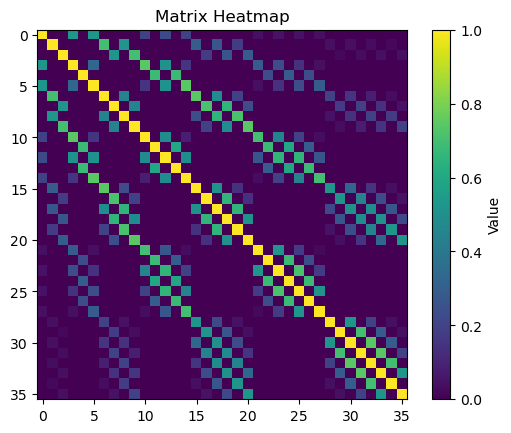

In [30]:
He_test = create_CGTOClass(np.array([0,0,0]), np.array([0.5, 0.2]), np.array([1.0, 1]), 7)
S_test = S_GTO_mat(He_test, He_test)
plot_map(S_test)

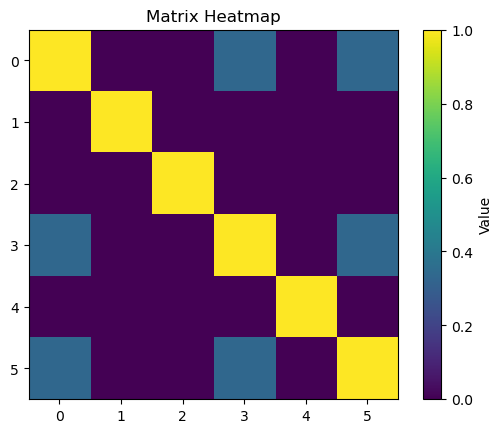

In [31]:
#STO3g example:
r1 = np.array([0.0, 0.0, 0.0])
r2 = np.array([0.0, 0.0, 1.4])
H_exps = np.array([3.42525091, 0.62391373, 0.16885540])
H_coeffs = np.array([0.15432897, 0.53532814, 0.44463454])

# Construct the CGTO (L=0)
H_1s_1 = create_CGTOClass(r1, H_exps, H_coeffs, 2)
H_1s_2 = create_CGTOClass(r2, H_exps, H_coeffs, 2)

S_1s1s_sto3g_self = S_GTO_mat(H_1s_1, H_1s_1)
plot_map(S_1s1s_sto3g_self)

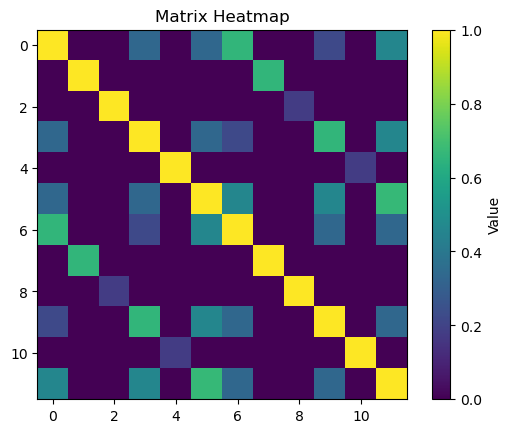

In [32]:
from pyscf import gto
mol = gto.M(
    atom = 'H 0 0 0; H 0 0 1.4',
    unit = 'Bohr', 
    basis = {'H': gto.basis.parse('''
        # This is the standard STO-3G definition
        # Exponent    Contraction Coeff
        H D
        3.42525091    0.15432897
        0.62391373    0.53532814
        0.16885540    0.44463454
    ''')},
    cart=True
)

mol.build()


overlap = mol.intor('int1e_ovlp')

#pyscf does not normalize in cartesian like this, we have to renormalize to compare
for i in range(len(overlap)):
    if overlap[i,i] != 1:
        overlap[i,:] /= overlap[i,i]

plot_map(overlap)